In [195]:
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import jax
import jax.random as jr
import arviz as az
import jax.scipy.special as jss
from functools import partial
# Import the custom package you generated
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)

num_dimensions = 500
num_data = 200
noise_magnitude_on_each_point = 1000
total_length = 20
# MAKE SURE NUM_FOURIER_ENTRIES IS EVEN
boundary_padding = 6
num_fitting_params = 2
hardcoded_logvar = 2
hardcoded_lognu = jnp.log(0.5)
num_integration_steps = 200
step_size = 0.015

num_fourier_entries = int(jnp.round(num_dimensions * (total_length + boundary_padding)/total_length))
normalization_factor = num_fourier_entries/jnp.sqrt(total_length + boundary_padding)


def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, lognu = inference_params
        # Scale is fixed
        logscale = 0
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))


freq_spacing = (total_length + boundary_padding) / num_fourier_entries
freqs = jnp.fft.fftfreq(num_fourier_entries, d=freq_spacing)
omegas = 2 * jnp.pi * freqs

def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))


def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_dimensions]

def fft_field(noise, inference_params):
    return fft_field_hartley(noise, inference_params)

def exponentiated_integrated_density(logdensity):
     return jnp.cumsum(jnp.exp(logdensity))

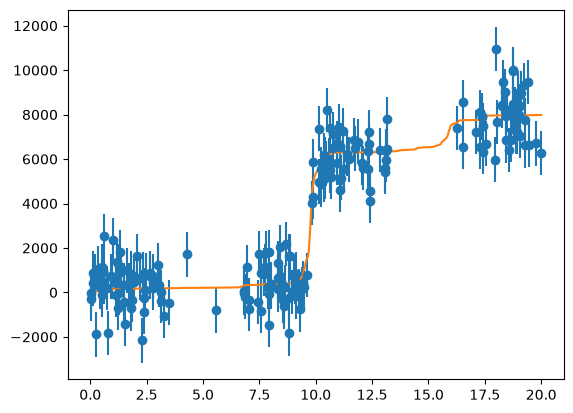

In [196]:
def cdf(x):
    return x + jnp.sin(4 * jnp.pi * x) / (4 * jnp.pi)

def pdf(x):
    return 1 + jnp.cos(4 * jnp.pi * x)

@partial(jax.jit, static_argnames=("n", "iters"))
def sample(key, n, iters=8):
    u = jr.uniform(key, (n,))
    x = u  # good initial guess since CDF(x) ≈ x on average
    for _ in range(iters):
        x = x - (cdf(x) - u) / pdf(x)   # Newton's method
        x = jnp.clip(x, 0.0, 1.0)
    return x


fixed_points_linspace = jnp.linspace(0, total_length, num_dimensions)
full_fourier_period_linspace = jnp.linspace(0, total_length + boundary_padding, num_fourier_entries)
diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2

cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2, k3, k4 = jr.split(jr.key(25), 4)
x_obs = sample(k1, num_data)*total_length
xi = jr.normal(k3, shape = num_fourier_entries)
true_field_raw = fft_field(xi, (hardcoded_logvar, hardcoded_lognu))
true_field_exp = exponentiated_integrated_density(true_field_raw)
y_obs_true = jnp.interp(x_obs, fixed_points_linspace, true_field_exp)
#y_obs_true = jnp.sin(30*x_obs/10) * jnp.exp(-5*x_obs/10)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)
noise = y_obs_err * jr.normal(k2, shape=y_obs_true.shape)
y_obs = y_obs_true + noise

plt.errorbar(x_obs, y_obs, yerr = noise_magnitude_on_each_point, fmt='o', label='Observations')

plt.plot(fixed_points_linspace, true_field_exp)
def response_function(xi, inference_params):
    field_points = exponentiated_integrated_density(fft_field(xi, inference_params))
    return jnp.interp(x_obs, fixed_points_linspace, field_points)


In [197]:
def logvarprior(logvar):
    return -0.5*logvar*logvar
def logscaleprior(logscale):
    return -0.5*logscale*logscale
def lognuprior(lognu):
    return -0.5*lognu*lognu

def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    xi = x[2:]
    inference_params = (logvar, lognu)
    negative_log_p_s = -logvarprior(logvar) - lognuprior(lognu) + 0.5*xi.T @ xi
    res = y_obs - response_function(xi, inference_params)
    negative_log_p_d_given_s = 0.5*res.T @ inv_cov_data_matrix @ res
    return negative_log_p_s + negative_log_p_d_given_s



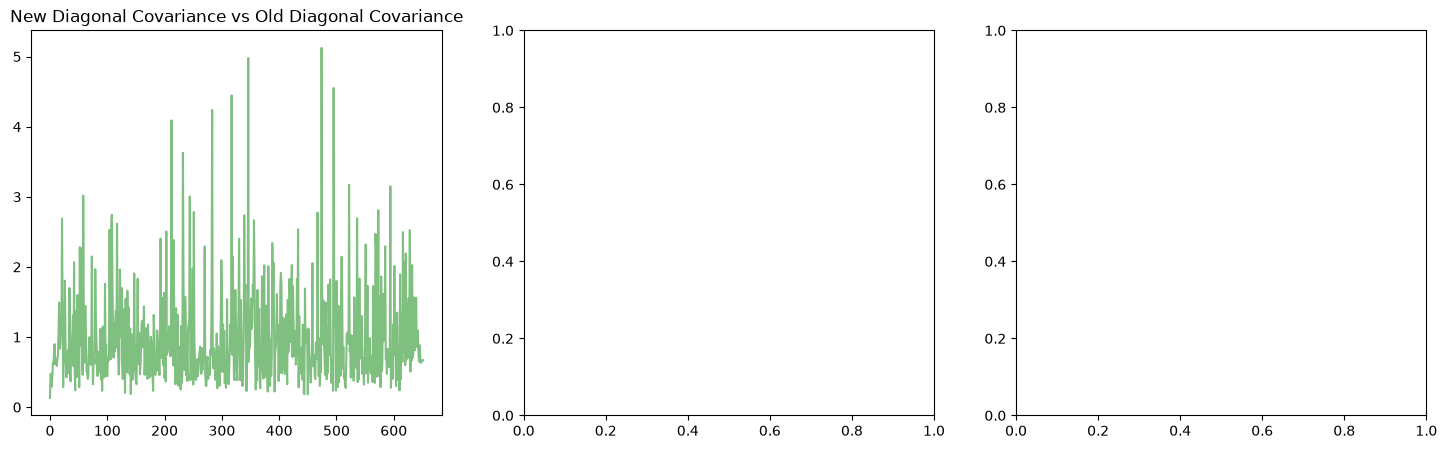

In [ ]:
num_overall_steps = 500
burn_in = 100
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)


##EVENING of 7/22: The raw_inv_mass_matrix is contaminated!
raw_inv_mass_matrix = jnp.array(np.load('cov_matrix_exp_int_fitting_variance_nu_matern.npy'))
D     = raw_inv_mass_matrix.shape[0]                 # 652
n_fit = num_fitting_params           # 2
n_low = 10                           # low-freq xi modes kept per end

constrained = jnp.concatenate([
    jnp.arange(n_fit + n_low),       # 0..11  : logvar, lognu, first 10 xi
    jnp.arange(D - n_low, D),        # 642..651: last 10 xi
])

mask = jnp.zeros(D, dtype=bool).at[constrained].set(True)
keep = mask[:, None] & mask[None, :]           # True only where BOTH indices are trusted

updated_inv_mass_matrix = jnp.where(keep, raw_inv_mass_matrix, jnp.eye(D))    # empirical on the block, identity elsewhere


sampler = HMCSampler(
    negative_logdensity= negative_logdensity,
    num_integration_steps=num_integration_steps,
    step_size=step_size,
    inv_mass_matrix = jnp.eye(num_fourier_entries + num_fitting_params),
    #inv_mass_matrix = updated_inv_mass_matrix,
    alpha=1.0
)

# 3. Setup execution seed and coordinates, then run!
rng = jr.PRNGKey(5)
initial_coordinates = jnp.zeros(num_fourier_entries + num_fitting_params)
#initial_coordinates = initial_coordinates.at[0].set(hardcoded_logvar)
#initial_coordinates = initial_coordinates.at[1].set(hardcoded_lognu)

overall_data_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)

logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
overall_position_arr = overall_data_arr[:, 2:]  
logscales = jnp.zeros_like(logvars)
inference_params = (logvars, lognus)

overall_position_arr_raw = jax.vmap(fft_field, in_axes=(0, 0))(
    overall_position_arr, inference_params
)
overall_position_arr_exp = jax.vmap(exponentiated_integrated_density, in_axes=(0))(
    overall_position_arr_raw
)
overall_position_arr_raw = overall_position_arr_raw[:, 0:num_dimensions]
overall_position_arr_exp = overall_position_arr_exp[:, 0:num_dimensions]

mean_position_raw = overall_position_arr_raw.sum(axis=0)/num_good_samples
mean_position_exp = overall_position_arr_exp.sum(axis=0)/num_good_samples
vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)
#old_cov = jnp.array(np.load('cov_matrix_fitting_three_parameters_matern.npy'))
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
timegrid = jnp.arange(num_fourier_entries + num_fitting_params)
axes[0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
#axes[0].plot(timegrid, jnp.diagonal(old_cov), color = "Red", alpha = 0.5)
axes[0].set_title("New Diagonal Covariance vs Old Diagonal Covariance")
#np.save('cov_matrix_exp_int_fitting_variance_nu_matern.npy', np.asarray(cov))

ESS for variance: 433.1501233772307
Num integration steps: 200 Step Size: 0.015
Num integration steps: 200 Step Size: 0.015
Average acceptance probability (acceptance rate) is: 0.9368405534024167
Num dimensions: 500 Num data: 200 Total length: 20 Noise on each point: 1000 Num HMC trials: 500


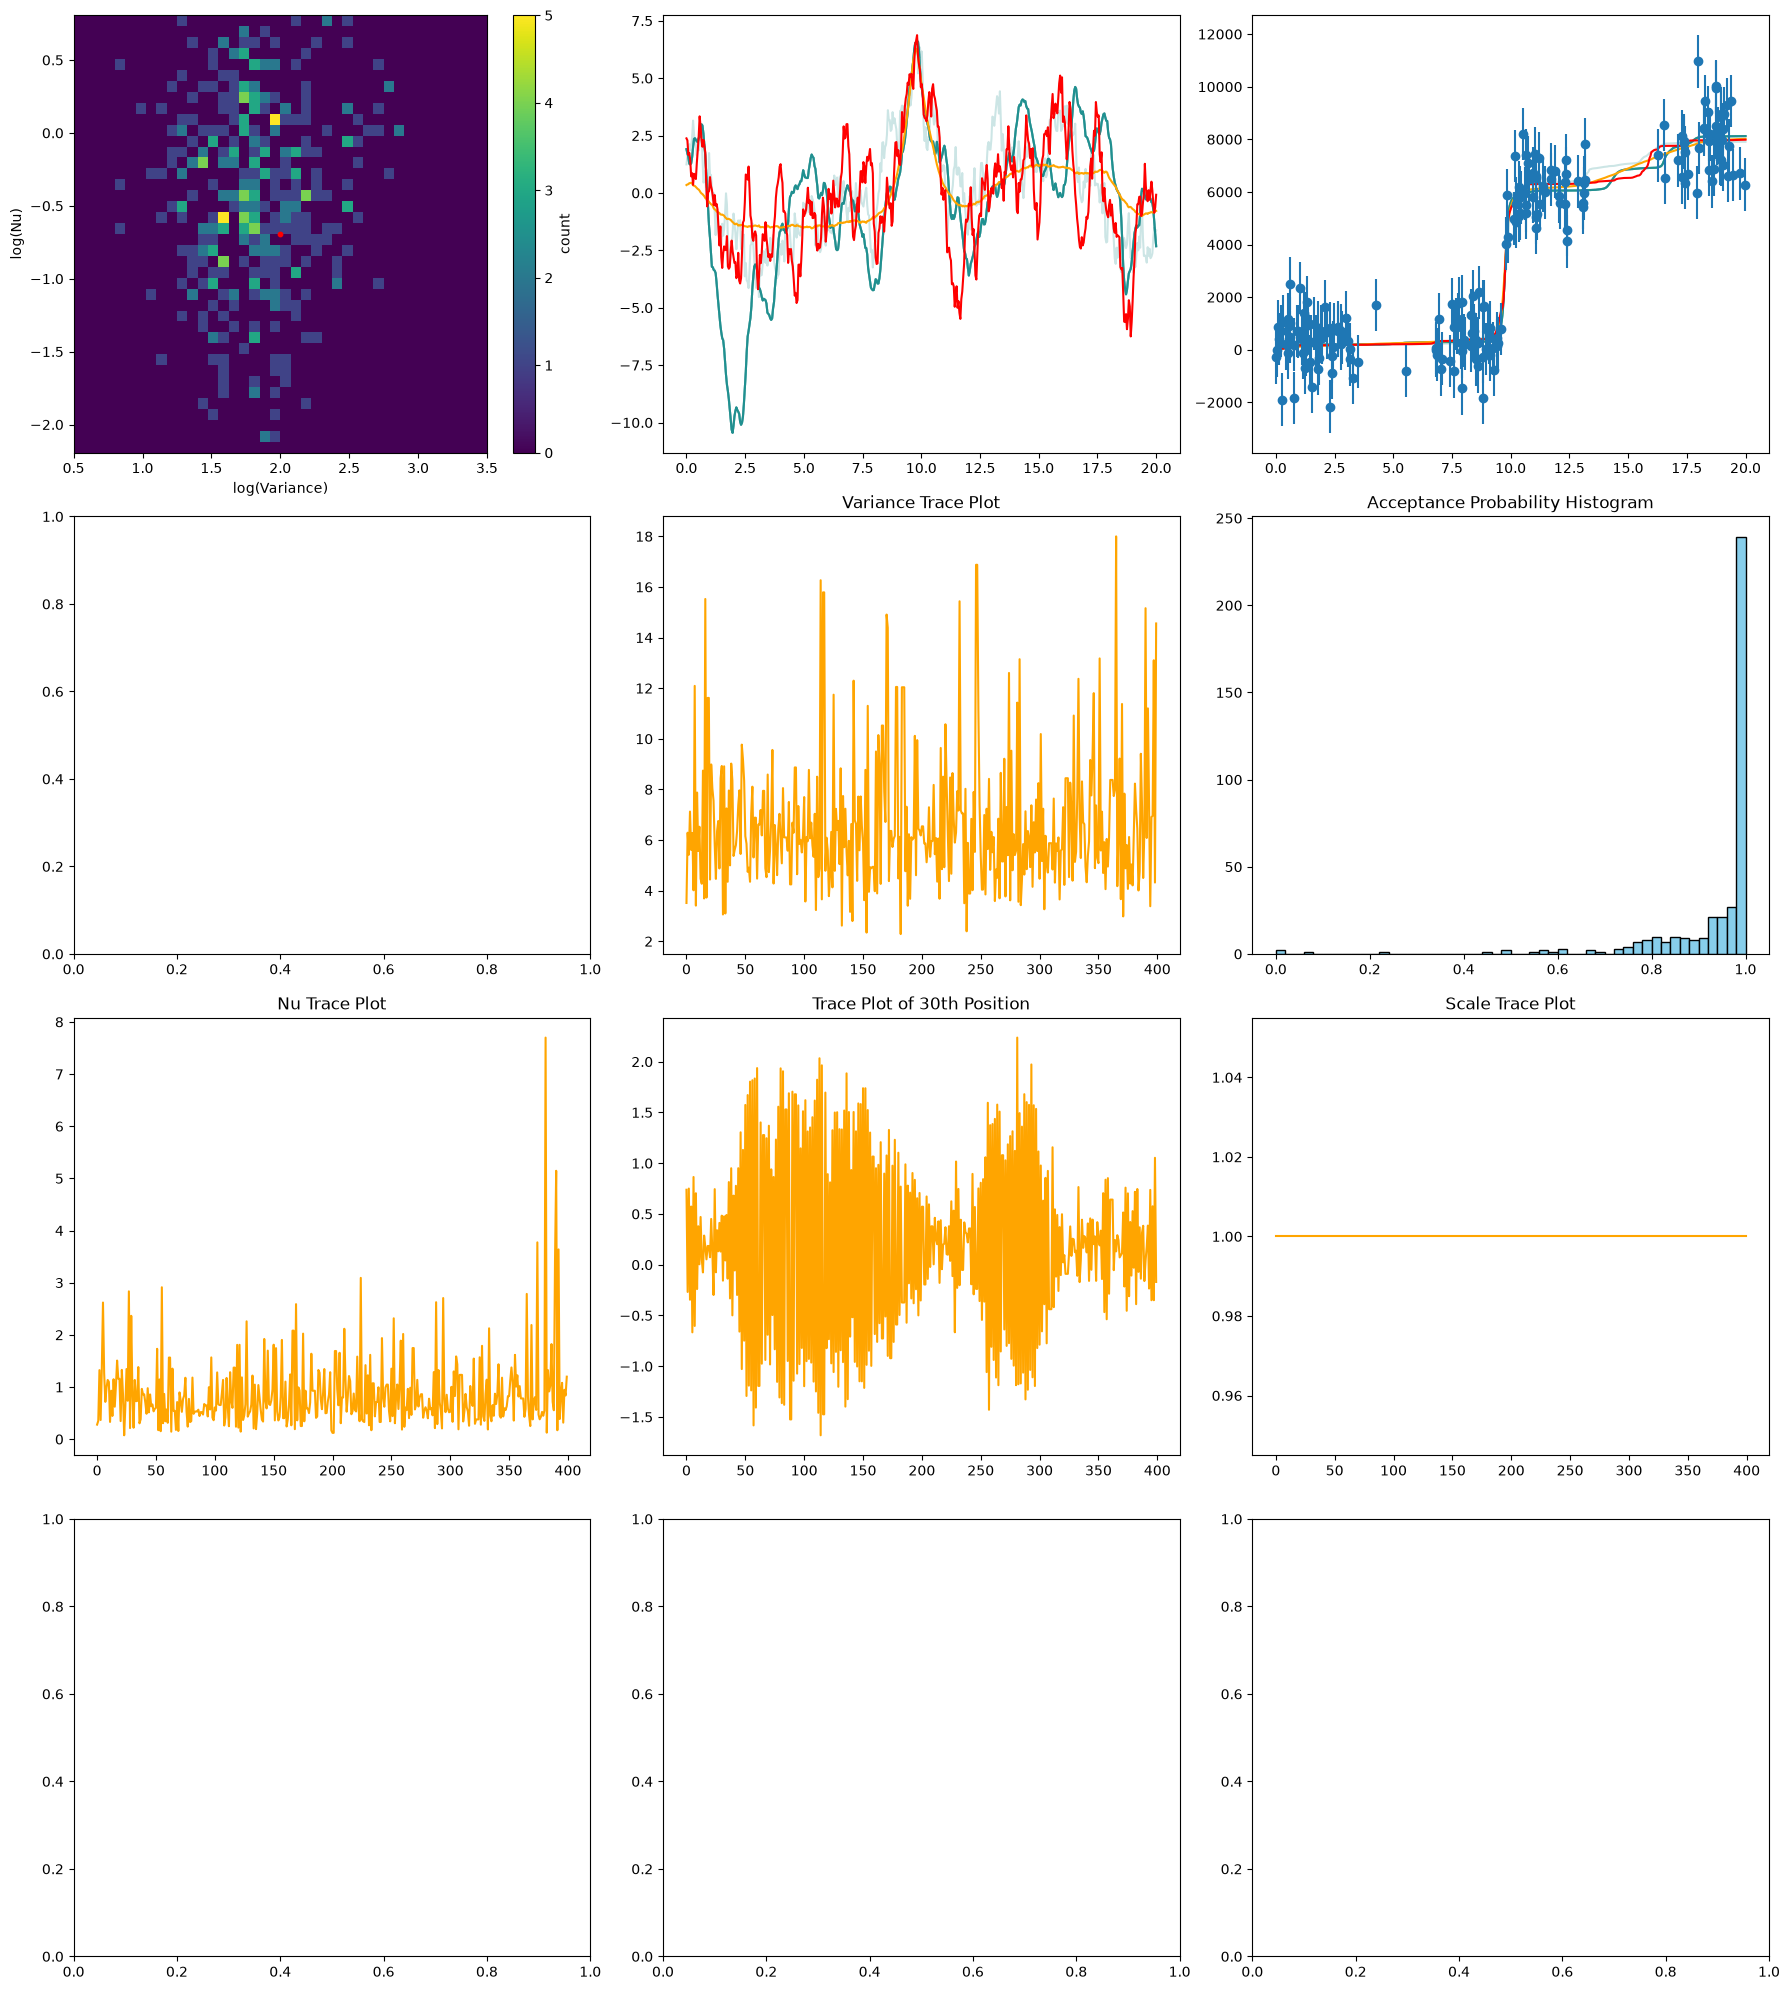

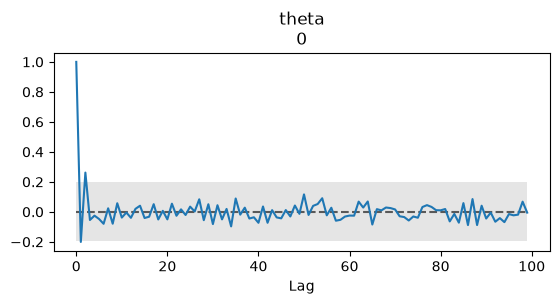

In [199]:
fig, axes = plt.subplots(4, 3, figsize = (18, 20))
for i in range (0, 10):
    axes[0][1].plot(fixed_points_linspace, overall_position_arr_raw[2000*i, :], color = "teal", alpha = 0.2)
    axes[0][2].plot(fixed_points_linspace, overall_position_arr_exp[2000*i, :], color = "teal", alpha = 0.2)
    

axes[0][1].plot(fixed_points_linspace, mean_position_raw, color = "orange", alpha = 1)
axes[0][1].plot(fixed_points_linspace, true_field_raw, color = "red", alpha = 1)
axes[0][2].plot(fixed_points_linspace, mean_position_exp, color = "orange", alpha = 1)
axes[0][2].plot(fixed_points_linspace, true_field_exp, color = "red", alpha = 1)
axes[0][2].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')


number_bins_x = 40
number_bins_y = 40
x_min, x_max = hardcoded_logvar - 1.5, hardcoded_logvar + 1.5
y_min, y_max = hardcoded_lognu - 1.5, hardcoded_lognu + 1.5
dx = (x_max - x_min)/number_bins_x
dy = (y_max - y_min)/number_bins_y

x_centers = (jnp.arange(number_bins_x) + 0.5)*dx + x_min
y_centers = (jnp.arange(number_bins_y) + 0.5)*dy + y_min
x_edges = jnp.arange(number_bins_x + 1)*dx + x_min
y_edges = jnp.arange(number_bins_y + 1)*dy + y_min

H_HMC_samples, _, _ = jnp.histogram2d(logvars, lognus, bins=[x_edges, y_edges])

im2 = axes[0][0].imshow(
    H_HMC_samples.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im2, ax=axes[0][0], label='count')

axes[0][0].scatter(hardcoded_logvar, hardcoded_lognu, color = 'red', s = 10, zorder = 3)
axes[0][0].set_xlabel("log(Variance)")
axes[0][0].set_ylabel("log(Nu)")
axes[1][1].plot(time_arr, vars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")
axes[2][2].plot(time_arr, scales, color = "Orange")
axes[2][2].set_title("Scale Trace Plot")
axes[2][0].plot(time_arr, nus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")
axes[2][1].plot(time_arr, overall_position_arr[:, 30], color = "Orange")
axes[2][1].set_title("Trace Plot of 30th Position")
axes[1][2].set_title("Acceptance Probability Histogram")
axes[1][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

fig.tight_layout()


posterior_samples = overall_data_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)

idata = az.from_dict({"posterior": {"theta": posterior_samples}})
param_index = 0  # which of your 50 parameters you want

az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [param_index]})

ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once

ess_param = ess_all["theta"].sel(theta_dim_0=param_index).values
print(f"ESS for variance: {ess_param}")
print(f"Num integration steps: {num_integration_steps} Step Size: {step_size}")
def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)
print(f"Num integration steps: {num_integration_steps} Step Size: {step_size}")
print(f"Average acceptance probability (acceptance rate) is: {jnp.average(accept_prob_arr)}")
print(f"Num dimensions: {num_dimensions} Num data: {num_data} Total length: {total_length} Noise on each point: {noise_magnitude_on_each_point} Num HMC trials: {num_overall_steps}")
